Oppgave 2a)

In [1]:
import numpy as np
from matplotlib import pyplot as plt

beta_k               = 1
antallPartikler       = 101
antallSimulasjoner    = 100
timeSteps            = 200

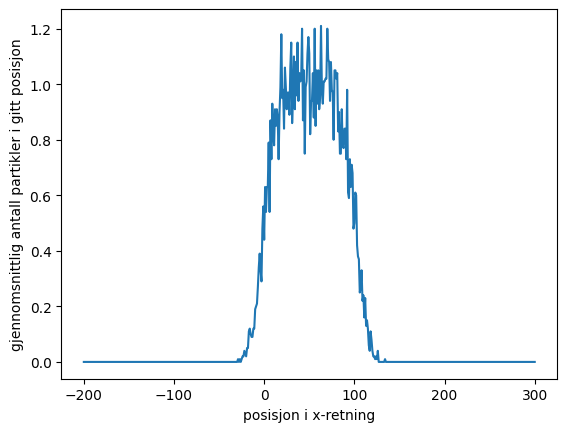

In [2]:
#HJELPEFUNKSJONER

#siden potensialfunksjonene er så simple finner vi at p_pos og p_neg er konstante for både V1 og V2 (altså uavhengig av x)
p_pos_V_i = 1/3
p_neg_V_i = 1/3



p_pos_V_ii = 1/(1 + np.exp(-2*beta_k) + np.exp(-beta_k))
p_neg_V_ii = np.exp(-2*beta_k) / (                  #må skrives slik for å ikke få overflow
    np.exp(-2*beta_k) + 1 + np.exp(-beta_k)
)


##### Main funksjonen som kjører simulasjonen

def enSimulasjon_2a(p_pos_V, p_neg_V):                           #kan være forskjellig potensialfunksjon

    partiklerPos = np.arange(0,antallPartikler)
    for _ in range(timeSteps):
        for i in range(len(partiklerPos)):
            tilfeldigtall = np.random.rand()

            if tilfeldigtall <= p_neg_V:
                partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos_V):
                partiklerPos[i] += 1

    return partiklerPos


def flereSimulasjoner_2a(p_pos_V, p_neg_V):


    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = enSimulasjon_2a(p_pos_V, p_neg_V)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    return totalPartikler


averageDist = flereSimulasjoner_2a(p_pos_V_i, p_neg_V_i)/antallSimulasjoner
x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)
plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
# plt.xlim(-50, 250)    # For å se litt nærmere
plt.show()

Oppgave 2b)

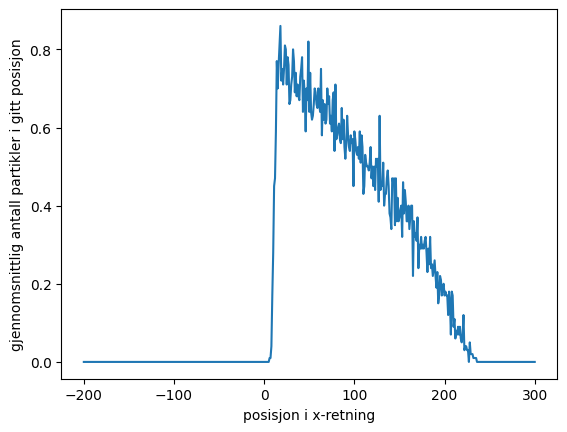

In [3]:
#gjenbruk av kode fra 2a
def enSimulasjon_2b(p_pos_V, p_neg_V):
    partiklerPos = np.arange(0,antallPartikler)
    partiklerPos_set = set(partiklerPos)
    for _ in range(timeSteps):
        tilfeldigRekkefølge = np.arange(0,antallPartikler)
        np.random.shuffle(tilfeldigRekkefølge)
        for i in tilfeldigRekkefølge:
            tilfeldigtall = np.random.rand()


            if tilfeldigtall <= p_neg_V:
                if (partiklerPos[i]-1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]-1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos_V):
                if (partiklerPos[i]+1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]+1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] += 1

    return partiklerPos



def flereSimulasjoner_2b(p_pos_V, p_neg_V):
    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = enSimulasjon_2b(p_pos_V, p_neg_V)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    return totalPartikler

averageDist = flereSimulasjoner_2b(p_pos_V_ii, p_neg_V_ii)/antallSimulasjoner
x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)
plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
plt.show()

In [ ]:
# Liten test
beta_k = 1000
x1 = np.linspace(0, 100, 101)
sannsynlighet = p_neg(x1, V_ii)
print(sannsynlighet)




[4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.92983827e-305 4.92983827e-305 4.92983827e-305
 4.92983827e-305 4.929838